# TUGAS TRANSFORMASI GEOMETRI

## 1. Titik Awal
Objek dibentuk dari titik-titik berikut:

A(-7, 2)

B(-4, 2)

C(-4, 4)

D(-7, 4)

A(-7, 2)

## 2. Refleksi terhadap Sumbu-Y
Setiap titik ditransformasikan:

Matriks refleksi:

 
 
Hasil refleksi:

A(-7, 2) → A’(7, 2)

B(-4, 2) → B’(4, 2)

C(-4, 4) → C’(4, 4)

D(-7, 4) → D’(7, 4)

## 3. Translasi
Translasi horizontal:

Matriks translasi (homogen):

 
 
Hasil translasi objek asli:

A(-7, 2) → A(-7 + t, 2)

B(-4, 2) → B(-4 + t, 2)

C(-4, 4) → C(-4 + t, 4)

D(-7, 4) → D(-7 + t, 4)

## 4. Transformasi Gabungan
Objek asli:

Objek refleksi:

Hasil refleksi + translasi:

A’(7, 2) → A’(7 - t, 2)

B’(4, 2) → B’(4 - t, 2)

C’(4, 4) → C’(4 - t, 4)

D’(7, 4) → D’(7 - t, 4)

## 5. Proses Berulang (Frame)
Nilai parameter berubah setiap iterasi:

Setiap nilai (t) menghasilkan posisi baru objek.

## 6. Kesimpulan
Objek pada bidang Kartesius bisa digeser dan dicerminkan menggunakan matriks. Refleksi membuat posisi kiri-kanan objek terbalik, sedangkan translasi menggeser objek secara perlahan mengikuti nilai ttt. Dari proses ini, terlihat dua objek bergerak berlawanan arah, tetapi bentuknya tetap sama.

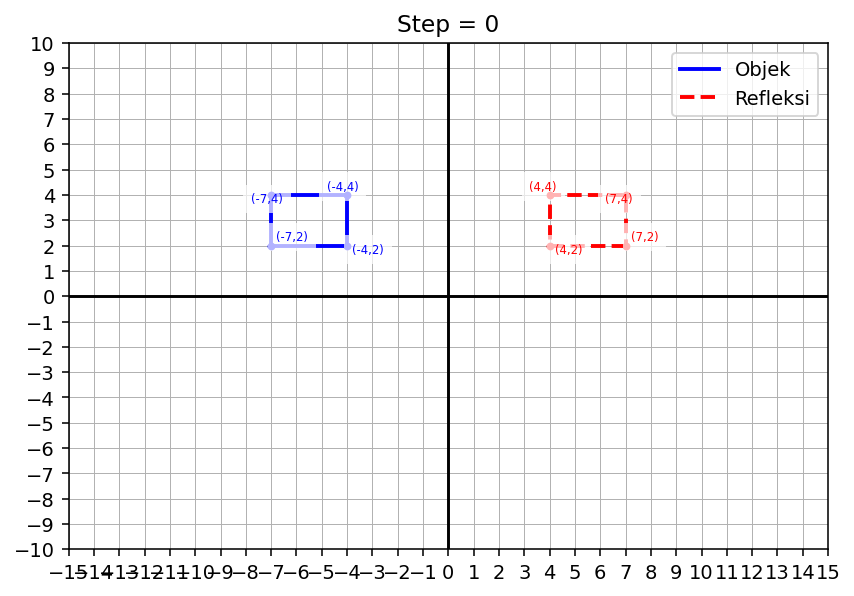

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# =========================
# OBJEK (KUADRAN II)
# =========================
objek = np.array([
  [-7, 2],
  [-4, 2],
  [-4, 4],
  [-7, 4],
  [-7, 2]
])

# =========================
# TRANSFORMASI
# =========================
R = np.array([
  [-1, 0],
  [0, 1]
])

def T(tx, ty):
  return np.array([
    [1, 0, tx],
    [0, 1, ty],
    [0, 0, 1]
  ])

def ke_homogen(obj):
  return np.hstack((obj, np.ones((obj.shape[0], 1))))

def ke_cartesian(obj):
  return obj[:, :2]

# =========================
# LABEL KOORDINAT
# =========================
def gambar_label(points, warna):
  offsets = [
    (0.2, 0.2),
    (0.2, -0.3),
    (-0.8, 0.2),
    (-0.8, -0.3)
  ]

  for i, (x, y) in enumerate(points[:-1]):
    dx, dy = offsets[i % 4]

    ax.plot(x, y, 'o', color=warna, markersize=3)

    ax.text(
      x + dx, y + dy,
      f"({x:.0f},{y:.0f})",
      fontsize=6,
      color=warna,
      bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
    )

# =========================
# PLOT (CANVAS PAS)
# =========================
plt.rcParams['figure.dpi'] = 140
fig, ax = plt.subplots(figsize=(7, 5))

def update(frame):
  ax.clear()

  ax.set_xlim(-15, 15)
  ax.set_ylim(-10, 10)
  ax.set_aspect('equal')

  # sumbu
  ax.axhline(0, color='black')
  ax.axvline(0, color='black')

  # grid rapat (angka berurutan)
  ax.set_xticks(np.arange(-15, 16, 1))
  ax.set_yticks(np.arange(-10, 11, 1))
  ax.grid(True, linewidth=0.5)

  # =========================
  # GERAK
  # =========================
  t = frame

  obj_h = ke_homogen(objek)

  # objek kiri → kanan
  kiri = (T(t, 0) @ obj_h.T).T
  kiri = ke_cartesian(kiri)

  # refleksi
  kanan_awal = (R @ objek.T).T
  kanan_h = ke_homogen(kanan_awal)

  # refleksi → kiri
  kanan = (T(-t, 0) @ kanan_h.T).T
  kanan = ke_cartesian(kanan)

  # gambar
  ax.plot(kiri[:, 0], kiri[:, 1], 'b-', linewidth=2, label='Objek')
  ax.plot(kanan[:, 0], kanan[:, 1], 'r--', linewidth=2, label='Refleksi')

  # label
  gambar_label(kiri, 'blue')
  gambar_label(kanan, 'red')

  ax.legend()
  ax.set_title(f"Step = {frame}")

# animasi
anim = FuncAnimation(fig, update, frames=15, interval=400)

HTML(anim.to_jshtml())